In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
import cv2

In [2]:
from segment_anything import SamPredictor,sam_model_registry
model_name = 'vit_b'
model_path = 'D:/Projects/Minor Project/Parameters/SAM-Parameter/sam_vit_b_01ec64.pth'

test_image_path = 'D:/Projects/Minor Project/Datasets/raw/testings_images/'

image = cv2.imread(test_image_path + "cat2.jpg")
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
print(image.shape)

sam = sam_model_registry[model_name](checkpoint=model_path)
predictor = SamPredictor(sam)
predictor.set_image(image)
image_embeddings = predictor.get_image_embedding()

scaled_h,scaled_w = predictor.input_size

features_h = scaled_h // 16
features_w = scaled_w // 16

valid_features = image_embeddings[:,:,:features_h,:features_w]

(1667, 2500, 3)


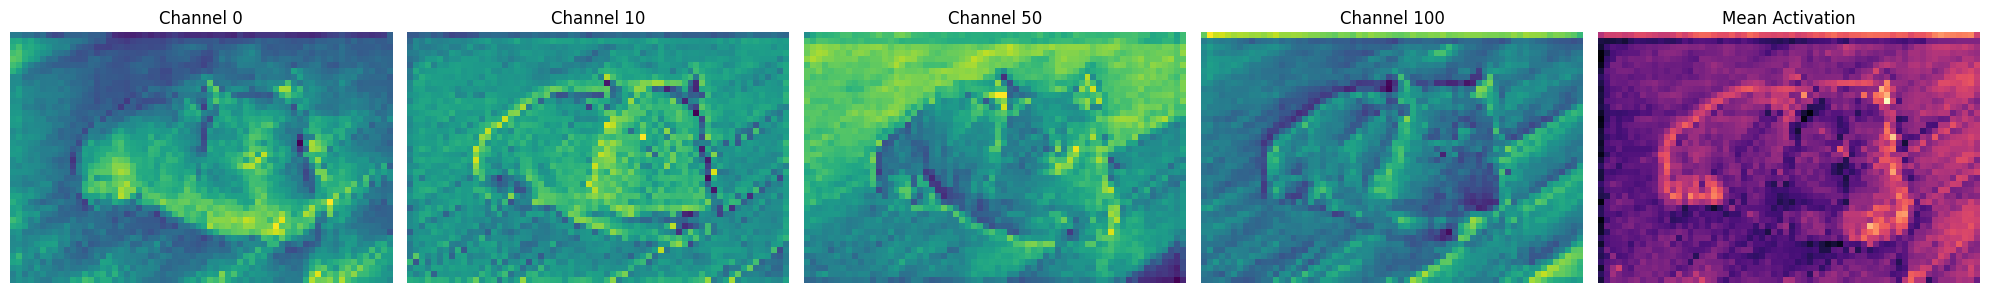

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Convert tensor to numpy and remove batch dim
# shape becomes [256, 64, 64]
features = valid_features.squeeze().cpu().detach().numpy()

# 2. Calculate the Mean Activation (Average of all 256 channels)
mean_feature = np.mean(features, axis=0)

# 3. Setup plotting for 4 individual channels + the Mean map
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

# Plot individual channels (e.g., channel 0, 10, 50, 100)
channels_to_view = [0, 10, 50, 100]

for i, ch_idx in enumerate(channels_to_view):
    axes[i].imshow(features[ch_idx], cmap='viridis')
    axes[i].set_title(f"Channel {ch_idx}")
    axes[i].axis('off')

# Plot the Mean Map
axes[4].imshow(mean_feature, cmap='magma')
axes[4].set_title("Mean Activation")
axes[4].axis('off')

plt.tight_layout()
plt.show()

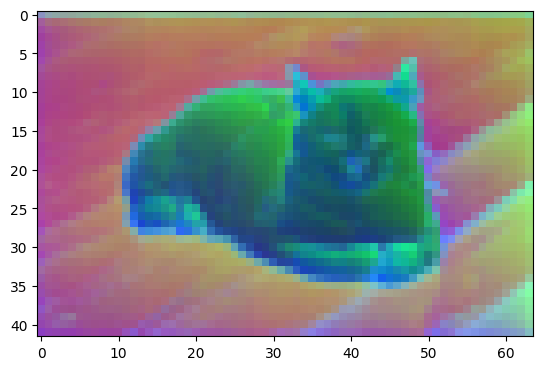

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

features = valid_features.cpu().numpy().reshape(256,-1).T

features_rgb = pca.fit_transform(features)

features_rgb = (features_rgb - features_rgb.min()) / (features_rgb.max() - features_rgb.min())\

features_rgb = features_rgb.reshape(features_h,features_w,3)

plt.imshow(features_rgb)

In [5]:
from nuscenes.utils.geometry_utils import view_points
from nuscenes.nuscenes import NuScenes,NuScenesExplorer
from nuscenes.utils.data_classes import LidarPointCloud
from pyquaternion import Quaternion
import os

data_path = 'D:/Projects/Minor Project/Datasets/raw/nuScenes'

Loading NuScenes tables for version v1.0-mini...
Loading nuScenes-lidarseg...
32 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
404 lidarseg,
Done loading in 0.572 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
[[6.05778276e+00 6.84423075e+00 8.03893691e+00 ... 1.59105444e+03
  1.58399246e+03 1.59425851e+03]
 [5.98363188e+02 5.61654430e+02 5.25800960e+02 ... 5.45090245e+02
  5.14287405e+02 5.14041152e+02]
 [1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 1.00000000e+00
  1.00000000e+00 1.00000000e+00]]
[19.996655 19.481045 19.458317 ... 17.63982  21.989788 21.797787]


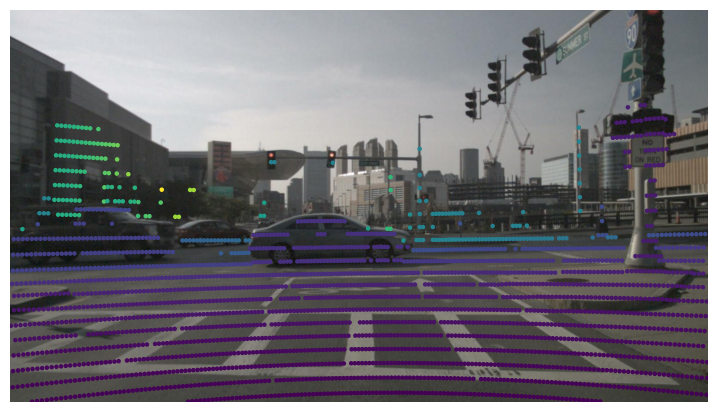

In [6]:
nusc = NuScenes(version='v1.0-mini',dataroot=data_path,verbose=True)
explorer = NuScenesExplorer(nusc)

my_sample = nusc.sample[87]

cam_token = my_sample['data']["CAM_FRONT"]
lidar_token = my_sample['data']["LIDAR_TOP"]

points,coloring,image = explorer.map_pointcloud_to_image(lidar_token,cam_token)

print(points)
print(coloring)

explorer.render_pointcloud_in_image(my_sample['token'],dot_size=5,render_intensity=False,show_lidarseg=False)

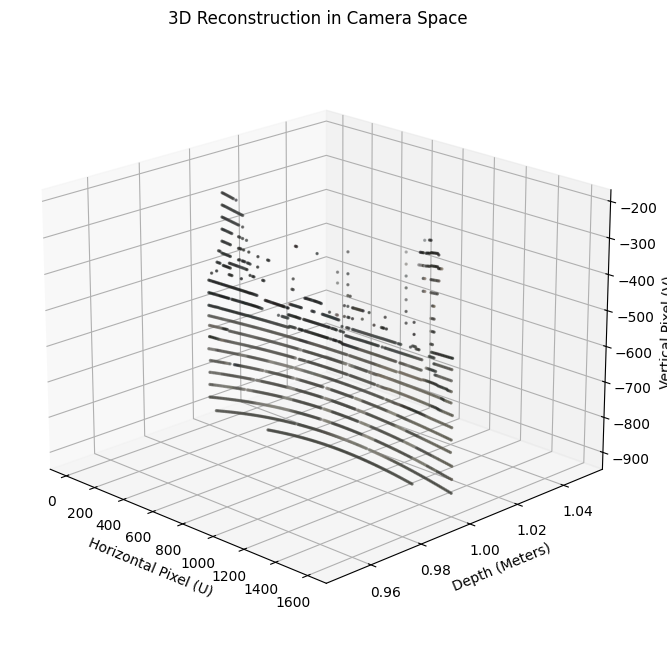

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. We use the 'points' and 'image' you already have from:
# points, coloring, image = explorer.map_pointcloud_to_image(lidar_token, cam_token)

# 2. Filter for points that actually fall within the image dimensions
# (In case there are points with negative coordinates or beyond the width/height)
mask = (points[0, :] >= 0) & (points[0, :] < image.size[0]) & \
       (points[1, :] >= 0) & (points[1, :] < image.size[1])

# 3. Extract the coordinates
u = points[0, mask]
v = points[1, mask]
depth = points[2, mask] # This is the 'coloring' values

# 4. Extract colors from the image for each valid point
point_colors = []
for i in range(len(u)):
    # Get RGB color at pixel (u, v)
    pixel_color = np.array(image.getpixel((int(u[i]), int(v[i])))) / 255.0
    point_colors.append(pixel_color)

# 5. Visualize in 3D using Matplotlib
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# We plot U (horizontal), Depth (forward), and -V (vertical)
# We use -V because image pixels count 'down' from the top, 
# but 3D plots count 'up'.
ax.scatter(u, depth, -v, c=point_colors, s=2, alpha=0.6)

# Labels
ax.set_xlabel('Horizontal Pixel (U)')
ax.set_ylabel('Depth (Meters)')
ax.set_zlabel('Vertical Pixel (V)')
ax.set_title('3D Reconstruction in Camera Space')

# Adjust the view for a better perspective
ax.view_init(elev=20, azim=-45)

plt.show()

In [11]:
import sys
import os

# 1. Replace this path with the actual location where you cloned the repo
# Example: 'C:/Users/Name/Projects/Depth-Anything-V2'
repo_path = os.path.abspath('D:/Projects/Minor Project/Depth-Anything-V2/')

# 2. Add it to the Python path
if repo_path not in sys.path:
    sys.path.append(repo_path)

In [13]:
import torch
import cv2
from depth_anything_v2.dpt import DepthAnythingV2

# Choose device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 1. Load Model
model_configs = {
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
}
# Using ViT-L as an example
model = DepthAnythingV2(**model_configs['vitl'])
model.load_state_dict(torch.load('D:/Projects/Minor Project/Parameters/DA-Parameter/depth_anything_v2_vits.pth', map_local='cpu'))
model.to(device).eval()

print("Depth Anything V2 is ready!")

TypeError: Unpickler.__init__() got an unexpected keyword argument 'map_local'

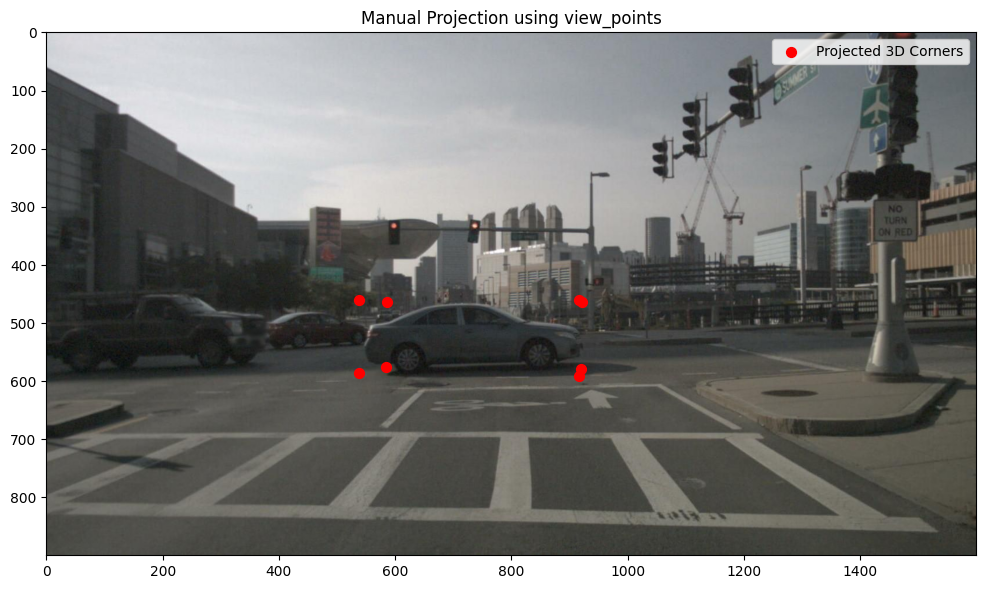

In [11]:
from nuscenes.utils.geometry_utils import view_points
import matplotlib.pyplot as plt

# 1. Setup camera data
# get_sample_data handles the transformation from Global -> Camera coordinates
data_path, boxes, camera_intrinsic = nusc.get_sample_data(cam_token)

# 2. Pick a specific car box from the sample
# (Let's take the first vehicle in the scene)
target_box = [b for b in boxes if 'vehicle' in b.name][0]

# 3. Get the 3D corners of that box (meters)
# This returns a [3, 8] array representing the 8 corners of the 3D cube
corners_3d = target_box.corners()

# 4. PROJECT THEM TO 2D (The view_points magic)
# normalize=True performs the perspective divide (making far things smaller)
corners_2d = view_points(corners_3d, camera_intrinsic, normalize=True)

# corners_2d is now [3, 8], where row 0 is U (X) and row 1 is V (Y)
u_coords = corners_2d[0, :]
v_coords = corners_2d[1, :]

# 5. Visualize to see the "skeleton" of the car
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.scatter(u_coords, v_coords, c='red', s=50, label='Projected 3D Corners')
plt.title("Manual Projection using view_points")
plt.legend()
plt.show()

In [7]:
depth_map = np.zeros((2,64,64),dtype=np.float32)

u_cord = points[0,:]
v_cord = points[1,:]

scaled_u = 64/1600
scaled_v = 64/900

for i in range(len(coloring)):
    u = int(u_cord[i] * scaled_u)
    v = int(v_cord[i] * scaled_v)

    if 0 <= u < 64 and 0 <= v < 64:
        depth_map[0,v,u] = coloring[i]
        depth_map[1,v,u] = 1.0

depth_tensor = torch.from_numpy(depth_map).unsqueeze(0)
print(coloring)
print(depth_tensor.shape)

[19.996655 19.481045 19.458317 ... 17.63982  21.989788 21.797787]
torch.Size([1, 2, 64, 64])


In [8]:
class DepthEncoder(nn.Module):
    def __init__(self,in_channel = 2, embeddings_channel = 256):
        super().__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channel,out_channels=64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2,inplace=True)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(64,128,kernel_size=3,padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2,inplace=True)
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(128,256,kernel_size=3,padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2,inplace=True)
        )

        self.final_projection = nn.Conv2d(256,embeddings_channel,kernel_size=1)


    def forward(self,x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        return self.final_projection(x)

depth_encoder = DepthEncoder()

In [ ]:
import sys
import os

# 1. Get the current directory (Minor Project/Notebook)
# 2. Get the parent directory (Minor Project)
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))

# 3. Add that parent directory to sys.path
if root_path not in sys.path:
    sys.path.append(root_path)